In [1]:
import geopandas as gpd
from matplotlib import pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator
import matplotlib
import seaborn as sns
import contextily as cx
import numpy as np
import pandas as pd
import xarray as xr
import rioxarray
import scipy.stats
sns.set_style("whitegrid")

MORTALITY_COLOR = "#fc8d62"
NONMORTALITY_COLOR = "#66c2a5"
BASEMAP = cx.providers.CartoDB.PositronNoLabels

PAPER_RC = {
    "font.size": 10
}

plt.rcParams.update(PAPER_RC)

### Map of areas of interest, severity distribution

In [2]:
dea_aois = gpd.read_file("../data_working/deadtrees_aoi.gpkg")
dea_aois["deadwood_areal_fraction"] = dea_aois["deadwood_area"] / dea_aois["aoi_area"]
dea_aois["plot_color"] = np.where(dea_aois["deadwood_areal_fraction"] > 0.05, MORTALITY_COLOR, NONMORTALITY_COLOR)

In [3]:
detections = gpd.read_file("../data_working/detections.parquet")
detections["plot_color"] = np.where(detections.tmin == -1, NONMORTALITY_COLOR, MORTALITY_COLOR)
detections = detections.sample(frac=1)

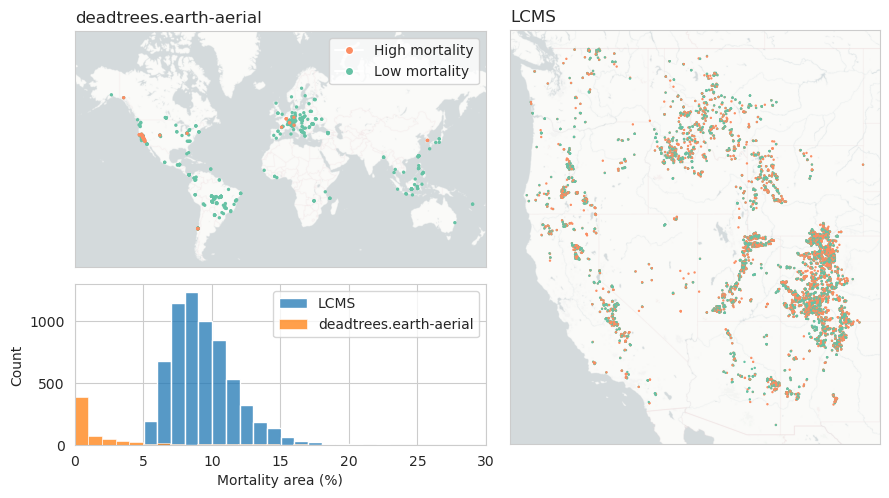

In [4]:
fig = plt.figure(figsize=(9, 5))
gs = matplotlib.gridspec.GridSpec(2, 2, width_ratios=[1, 0.9], height_ratios=[0.75, 0.5])
dea_ax = fig.add_subplot(gs[0, 0])
lcms_ax = fig.add_subplot(gs[:, 1])
hist_ax = fig.add_subplot(gs[1, 0])

marker_legend = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=MORTALITY_COLOR, label="High mortality"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor=NONMORTALITY_COLOR, label="Low mortality")
]

world_bbox_3857 = -20_037_508.34, -20_037_508.34, 20_037_508.34, 20_037_508.34

# DEA map
dea_aois = dea_aois.sort_values("plot_color")
dea_aois.to_crs(3857).centroid.plot(ax=dea_ax, markersize=2, color=dea_aois["plot_color"])
cx.add_basemap(dea_ax, source=BASEMAP, attribution=False)
dea_ax.set_xlim(world_bbox_3857[0], world_bbox_3857[-1])
dea_ax.set_ylim(-0.8e7, 1.5e7)
dea_ax.set_xticks([])
dea_ax.set_yticks([])
dea_ax.set_title("deadtrees.earth-aerial", loc="left")
dea_ax.legend(handles=marker_legend)

# LCMS map
detections.centroid.to_crs(3857).plot(markersize=0.5, c=detections["plot_color"], ax=lcms_ax)
cx.add_basemap(lcms_ax, source=BASEMAP, attribution=False)
lcms_ax.set_xticks([])
lcms_ax.set_yticks([])
lcms_ax.set_title("LCMS", loc="left")

# Histogram
lcms_severity = detections[(detections.tmin != -1) & (detections.severity >= 5)].severity
dea_severity  = dea_aois["deadwood_areal_fraction"] * 100

sns.histplot(lcms_severity, binwidth=1, label="LCMS", ax=hist_ax)
sns.histplot(dea_severity, binwidth=1, label="deadtrees.earth-aerial", ax=hist_ax)
hist_ax.legend()
hist_ax.set_xlabel("Mortality area (%)")
hist_ax.set_xlim(0, 30)

plt.tight_layout()

plt.show()

### Examples of LCMS AOI timeseries

In [5]:
lcms = xr.open_zarr(
    "s3://nasa-cryo-persistent/ganzk/lcms/lcms.zarr/"
).assign_coords(band=["Drought mortality", "Fire mortality", "Total mortality"])

lcms = lcms.rio.write_crs("EPSG:5071")

In [6]:
my_bbox = detections.geometry.iloc[0].bounds

In [7]:
detections

,tmin,tmax,severity,geometry,plot_color
4675,2017,2018,9.570312,"POLYGON ((-992250 1739550, -992250 1739850, -9...",#fc8d62
10377,-1,-1,0.000000,"POLYGON ((-2021850 1780950, -2021850 1781250, ...",#66c2a5
1918,2017,2017,8.081055,"POLYGON ((-905550 2056050, -905550 2056350, -9...",#fc8d62
12250,-1,-1,0.000000,"POLYGON ((-980850 1707150, -980850 1707450, -9...",#66c2a5
9522,-1,-1,0.000000,"POLYGON ((-799650 1811550, -799650 1811850, -7...",#66c2a5
...,...,...,...,...,...
3886,2013,2013,0.000181,"POLYGON ((-1656150 1772550, -1656150 1772850, ...",#fc8d62
10107,-1,-1,0.000000,"POLYGON ((-913950 1569450, -913950 1569750, -9...",#66c2a5
4278,2017,2017,9.545898,"POLYGON ((-1051050 1762050, -1051050 1762350, ...",#fc8d62
10929,-1,-1,0.000000,"POLYGON ((-961050 1505850, -961050 1506150, -9...",#66c2a5


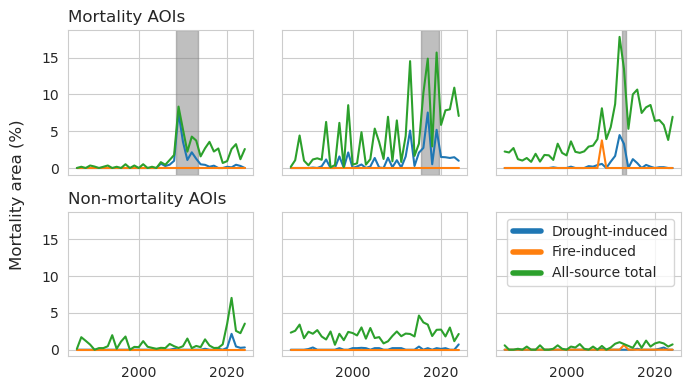

In [8]:
from itertools import chain

fig, axes = plt.subplots(2, 3, sharex=True, sharey=True, figsize=(7, 4))

mortality_geoms = detections[(detections.tmin != -1) & (detections.severity > 10)].sample(3, random_state=35)
nonmort_geoms   = detections[detections.tmin == -1].sample(3, random_state=0)

for i, (idx, row) in enumerate(chain(mortality_geoms.iterrows(), nonmort_geoms.iterrows())):
    lcms.rio.clip_box(*row.geometry.bounds)\
        .mean(dim=["x", "y"]).band_data\
        .plot(ax=axes.flat[i], x="time", hue="band", add_legend=False)
    # Highlight the mortality event
    if row["tmin"] != -1:
        axes.flat[i].axvspan(row["tmin"]-0.5, row["tmax"]+0.5, color="gray", alpha=0.5)
    axes.flat[i].set_title("")
    axes.flat[i].set_xlabel("")
    axes.flat[i].set_ylabel("")

axes[0, 0].set_title("Mortality AOIs", loc="left")
axes[1, 0].set_title("Non-mortality AOIs", loc="left")

band_legend = [
    Line2D([0], [0], color="C0", lw=4, label="Drought-induced"),
    Line2D([0], [0], color="C1", lw=4, label="Fire-induced"),
    Line2D([0], [0], color="C2", lw=4, label="All-source total")
]

axes.flat[-1].legend(handles=band_legend)
fig.supylabel("Mortality area (%)")
plt.tight_layout()
plt.show()

### LCMS standardized/unstandardized NDVI, VH backscatter

In [9]:
ann_summary = pd.read_parquet("../data_working/ann_summary_lcms.parquet")
ann_summary["mort_group"] = ann_summary["mort_group"].map({"mort": "Mortality", "non-mort": "Non-mortality"})

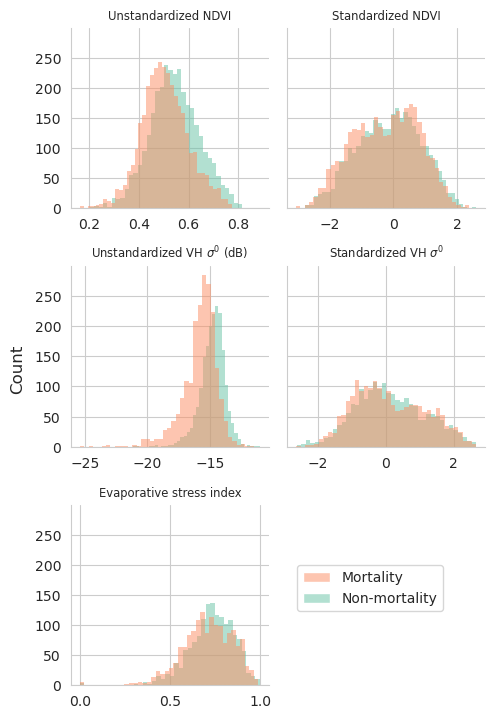

In [22]:
facet = sns.displot(
    data=ann_summary.loc[:, 0, ["ndvi300_ndvi", "ndvi300_ndvi_std", "VH", "VH_std", "ESI"]], 
    x='value',
    hue="mort_group",
    col='variable', kind='hist', col_wrap=2,
    common_bins=False,
    bins=40,
    facet_kws=dict(sharex=False, legend_out=False),
    palette={"Mortality":MORTALITY_COLOR, "Non-mortality":NONMORTALITY_COLOR},
    height=2.5
)

plt.gcf().supxlabel("")
plt.gcf().supylabel("Count")
facet.set_axis_labels("", "")
facet.axes.flat[0].set_title("Unstandardized NDVI", fontsize="small")
facet.axes.flat[1].set_title("Standardized NDVI", fontsize="small")
facet.axes.flat[2].set_title("Unstandardized VH $\\sigma^0$ (dB)", fontsize="small")
facet.axes.flat[3].set_title("Standardized VH $\\sigma^0$", fontsize="small")
facet.axes.flat[4].set_title("Evaporative stress index", fontsize="small")
facet.legend.set_title("")
sns.move_legend(facet, loc=(0.60, 0.15))

plt.show()

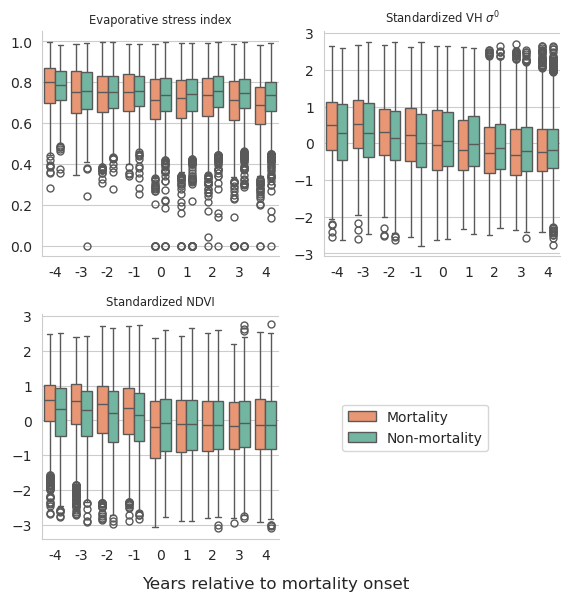

In [31]:
facet = sns.catplot(
    data=ann_summary.loc[:, slice(-4, 4), ["ndvi300_ndvi_std", "VH_std", "ESI"]], 
    x='obs_year_rel', y='value',
    hue="mort_group",
    sharex=False, sharey=False,
    col='variable', kind='box',
    height=3,
    col_wrap=2,
    legend_out=False,
    palette={"Mortality":MORTALITY_COLOR, "Non-mortality":NONMORTALITY_COLOR},
    formatter=lambda x: f"{x:.0f}"
)

plt.gcf().supxlabel("Years relative to mortality onset")
facet.set_axis_labels("", "")
facet.axes.flat[0].set_title("Evaporative stress index", fontsize="small")
facet.axes.flat[1].set_title("Standardized VH $\\sigma^0$", fontsize="small")
facet.axes.flat[2].set_title("Standardized NDVI", fontsize="small")
facet.legend.set_title("")
sns.move_legend(facet, loc=(0.60, 0.25))

plt.show()

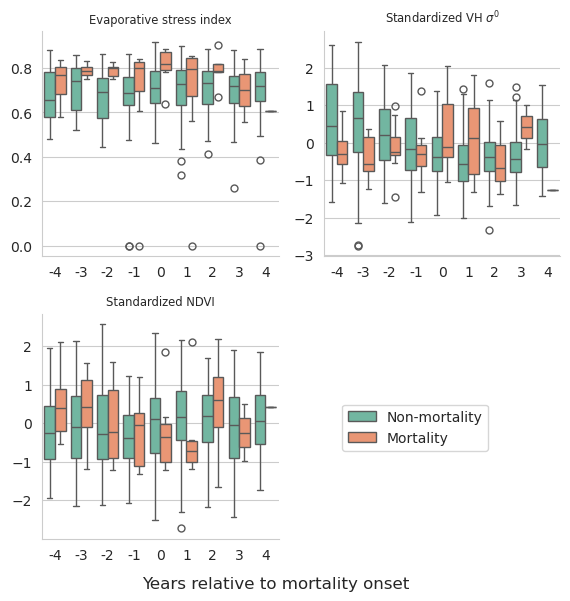

In [33]:
ann_summary_dea = pd.read_parquet("../data_working/ann_summary_deadtrees.parquet")
ann_summary_dea["mort_group"] = ann_summary_dea["mort_group"].map({"mort":"Mortality", "non-mort":"Non-mortality"})

facet = sns.catplot(
    data=ann_summary_dea.loc[:, slice(-4, 4), ["ndvi300_ndvi_std", "VH_std", "ESI"]], 
    x='obs_year_rel', y='value',
    hue="mort_group",
    sharex=False, sharey=False,
    col='variable', kind='box',
    height=3,
    col_wrap=2,
    legend_out=False,
    palette={"Mortality":MORTALITY_COLOR, "Non-mortality":NONMORTALITY_COLOR},
    formatter=lambda x: f"{x:.0f}"
)

plt.gcf().supxlabel("Years relative to mortality onset")
facet.set_axis_labels("", "")
facet.axes.flat[0].set_title("Evaporative stress index", fontsize="small")
facet.axes.flat[1].set_title("Standardized VH $\\sigma^0$", fontsize="small")
facet.axes.flat[2].set_title("Standardized NDVI", fontsize="small")
facet.legend.set_title("")
sns.move_legend(facet, loc=(0.60, 0.25))

plt.show()

### Trend in annual spectral power at mortality onset

In [14]:
ndvi_power_at_onset

,mort_group,onset_year,rel_smax_at_onset,smax_trend_at_onset,source
0,Mortality,2024,0.632471,0.067643,lcms
1,Mortality,2021,0.188465,-0.219354,lcms
2,Mortality,2015,0.903929,NaN,lcms
4,Mortality,2021,0.264251,-0.149850,lcms
7,Mortality,2021,0.117295,-0.092594,lcms
...,...,...,...,...,...
122,Non-mortality,2025,0.261163,0.025025,dea
123,Non-mortality,2025,0.536034,-0.024453,dea
124,Non-mortality,2024,0.628291,0.018960,dea
125,Non-mortality,2023,0.358576,0.066676,dea


In [15]:
lcms_ndvi_power = pd.read_parquet("../data_working/power_at_onset_lcms.parquet")
lcms_ndvi_power["source"] = "lcms"
dea_ndvi_power  = pd.read_parquet("../data_working/power_at_onset_deadtrees.parquet")
dea_ndvi_power["source"] = "dea"

ndvi_power_at_onset = pd.concat([lcms_ndvi_power, dea_ndvi_power]).reset_index()
ndvi_power_at_onset["mort_group"] = ndvi_power_at_onset["mort_group"].map({"mort": "Mortality", "non-mort": "Non-mortality"})
ndvi_power_at_onset["smax_trend_at_onset"] *= 365

In [91]:
# Run t-tests
ttests_smax_trend = []
for group, data in ndvi_power_at_onset.groupby("source"):
    smax_mort = data["smax_trend_at_onset"][data["mort_group"] == "Mortality"]
    smax_nonmort = data["smax_trend_at_onset"][data["mort_group"] == "Non-mortality"]

    test_result = scipy.stats.ttest_ind(smax_mort, smax_nonmort, equal_var=False, nan_policy="omit", alternative="less")
    print(group)
    print(test_result)
    print(test_result.confidence_interval())
    ttests_smax_rel.append(
        (group, test_result)
    )

dea
TtestResult(statistic=0.6071585110705053, pvalue=0.7209820135618221, df=9.460036622471693)
ConfidenceInterval(low=-inf, high=0.04005382091534078)
lcms
TtestResult(statistic=-2.3256783846007845, pvalue=0.010039366541426707, df=4625.867899130549)
ConfidenceInterval(low=-inf, high=-0.0018321837575682402)


In [83]:
from math import floor, log10

# https://stackoverflow.com/questions/18311909/how-do-i-annotate-with-power-of-ten-formatting
# Define function for string formatting of scientific notation
def sci_notation(num, decimal_digits=1, precision=None, exponent=None):
    """
    Returns a string representation of the scientific
    notation of the given number formatted for use with
    LaTeX or Mathtext, with specified number of significant
    decimal digits and precision (number of decimal digits
    to show). The exponent to be used can also be specified
    explicitly.
    """
    if exponent is None:
        exponent = int(floor(log10(abs(num))))
    coeff = round(num / float(10**exponent), decimal_digits)
    if precision is None:
        precision = decimal_digits

    return r"${0:.{2}f}\times10^{{{1:d}}}$".format(coeff, exponent, precision)

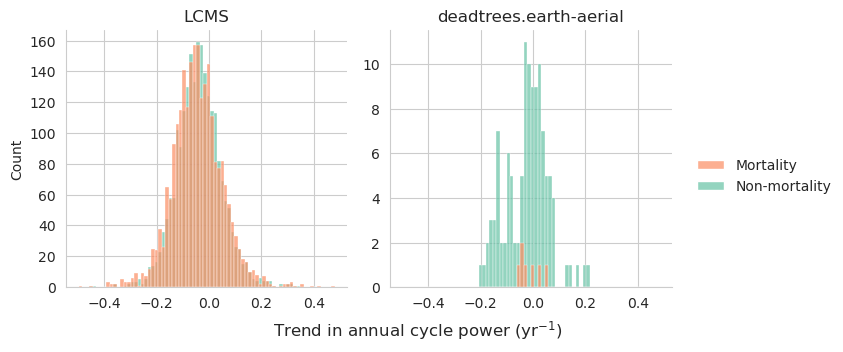

In [89]:
hist = sns.displot(
    ndvi_power_at_onset,
    x="smax_trend_at_onset",
    col="source",
    kind="hist",
    hue="mort_group",
    common_bins=True,
    palette={"Mortality":MORTALITY_COLOR, "Non-mortality":NONMORTALITY_COLOR},
    alpha=0.7,
    height=3.5,
    facet_kws=dict(
        sharex=False,
        sharey=False
    )
)

hist.axes.flat[0].set_title("LCMS")
hist.axes.flat[1].set_title("deadtrees.earth-aerial")

for ax in hist.axes.flat:
    ax.set_xlabel("")

hist.legend.set_title("")
plt.gcf().supxlabel("Trend in annual cycle power (yr$^{-1}$)")
plt.show()

In [90]:
ttests_smax_rel = []
for group, data in ndvi_power_at_onset.groupby("source"):
    smax_mort = data["rel_smax_at_onset"][data["mort_group"] == "Mortality"]
    smax_nonmort = data["rel_smax_at_onset"][data["mort_group"] == "Non-mortality"]

    test_result = scipy.stats.ttest_ind(smax_mort, smax_nonmort, equal_var=False, nan_policy="omit", alternative="less")
    print(group)
    print(test_result)
    print(test_result.confidence_interval())
    ttests_smax_rel.append(
        (group, test_result)
    )

dea
TtestResult(statistic=-0.9280103127263963, pvalue=0.19257237657744453, df=6.803058815906251)
ConfidenceInterval(low=-inf, high=0.07682021774220674)
lcms
TtestResult(statistic=-6.034678523381763, pvalue=8.428270260326127e-10, df=6145.072868667871)
ConfidenceInterval(low=-inf, high=-0.027275182799688255)


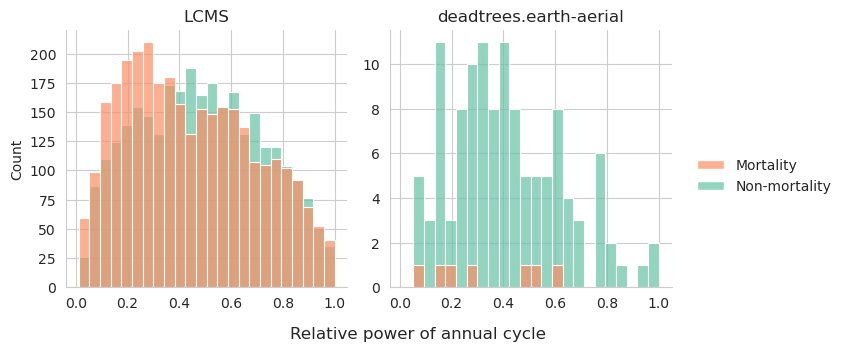

In [92]:
hist = sns.displot(
    ndvi_power_at_onset,
    x="rel_smax_at_onset",
    col="source",
    kind="hist",
    hue="mort_group",
    common_bins=True,
    palette={"Mortality":MORTALITY_COLOR, "Non-mortality":NONMORTALITY_COLOR},
    alpha=0.7,
    height=3.5,
    facet_kws=dict(
        sharex=False,
        sharey=False
    )
)

hist.axes.flat[0].set_title("LCMS")
hist.axes.flat[1].set_title("deadtrees.earth-aerial")

for ax in hist.axes.flat:
    ax.set_xlabel("")

hist.legend.set_title("")
plt.gcf().supxlabel("Relative power of annual cycle")
plt.show()